Example Plots for Simulated Annealing

In [2]:
brute_force_data_paths = [
    'data/brute_force/candidate_space_1048576_instances_1_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_9_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_33_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_42_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_57_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_99_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_100_seed_2026-03-28_15-52-55.csv',
    'data/brute_force/candidate_space_1048576_instances_110_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_808_seed_2026-03-28_15-53-27.csv',
    'data/brute_force/candidate_space_1048576_instances_5004_seed_2026-03-28_15-16-30.csv',
]
boundss = [
    [(0, 4)] * 10
] * 10

In [3]:
import pandas as pd

brute_force_data = [pd.read_csv(p) for p in brute_force_data_paths]

In [4]:
from cl_optimizer import SimulatedAnnealing
sim_anns = [
        SimulatedAnnealing(
        lookup_table=data,
        bounds=bounds,
    ) for data, bounds in zip(brute_force_data, boundss)
]

In [5]:
import numpy as np
# I think init and end temperatures should be chosen dependent on the delta of the energy,
# i.e. delta = new_loss - old_loss (in the exponent)
# larger delta -> larger temperature (and conversely smaller beta)
init_temp = 100
end_temp = 1
max_temp_iterations = 80

def execute_sim_ann(df_id: int, sim_ann: SimulatedAnnealing, temp_iterations: list[int]) -> np.ndarray:
    optima = []
    for iterations in temp_iterations:
        print(f"Temp. Iterations {iterations}")
        temp_schedule = SimulatedAnnealing.geometric_temp_schedule(init_temp, end_temp, iterations)
        _, loss = sim_ann.optimize(
            temp_schedule=temp_schedule,
            verbose=False
        )
        optima.append(loss)

    return np.concat(([df_id], temp_iterations, optima))

In [6]:
from parallelization import construct_parallelization_arg_list

arg_list = construct_parallelization_arg_list(sim_anns, depth=max_temp_iterations)

In [7]:
from joblib import Parallel, delayed

print(f"Preparing to execute {len(arg_list)} in parallel.")
results = np.array(
    Parallel(n_jobs=-1, verbose=11)(
    delayed(execute_sim_ann)(s_id, sim_ann, temp_iterations) for (s_id, sim_ann), temp_iterations in arg_list)
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   54.6s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   56.0s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:   57.2s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:   59.9s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  2

In [11]:
from parallelization import extract_sorted_losses_and_temps

sorted_temps, sorted_losses = extract_sorted_losses_and_temps(results)

In [12]:
min_loss = np.array([data['loss'].min() for data in brute_force_data])
max_loss = np.array([data['loss'].max() for data in brute_force_data])
approximation_ratios = (1 - (sorted_losses.T - min_loss) / (max_loss - min_loss)).mean(axis=1)

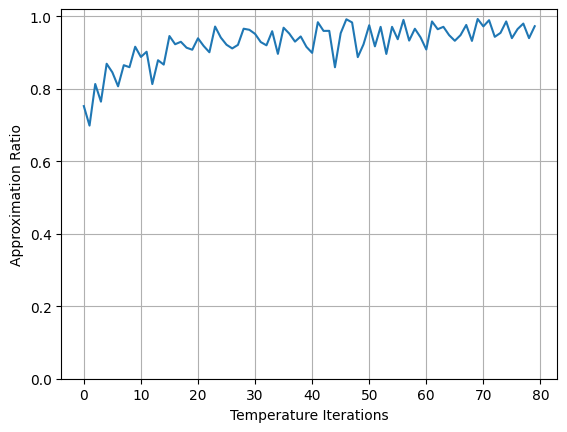

In [13]:
from matplotlib import pyplot as plt

plt.plot(
    range(sorted_losses.shape[1]),
    approximation_ratios
)
plt.ylim([0, 1.02])
plt.ylabel('Approximation Ratio')
plt.xlabel('Temperature Iterations')
plt.grid(visible=True)